Model training demo implementation

In [2]:
!pip install catboost

   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 1.0/100.2 MB 6.3 MB/s eta 0:00:16
    --------------------------------------- 1.8/100.2 MB 4.6 MB/s eta 0:00:22
    --------------------------------------- 2.1/100.2 MB 4.5 MB/s eta 0:00:22
   - -------------------------------------- 3.1/100.2 MB 3.9 MB/s eta 0:00:25
   - -------------------------------------- 3.9/100.2 MB 3.9 MB/s eta 0:00:26
   - -------------------------------------- 4.2/100.2 MB 3.9 MB/s eta 0:00:25
   - -------------------------------------- 4.2/100.2 MB 3.9 MB/s eta 0:00:25
   - -------------------------------------- 4.2/100.2 MB 3.9 MB/s eta 0:00:25
   - -------------------------------------- 4.2/100.2 MB 3.9 MB/s eta 0:00:25
   - -------------------------------------- 4.2/100.2 MB 3.9 MB/s eta 0:00:25
   - -------------------------------------- 4.2/100.2 MB 3.9 MB/s eta 0:00:25
   - -------------------------------------- 4.2/100.2 MB 3.9 MB/s eta 0

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

import warnings 
warnings.filterwarnings('ignore')

'''Modelling '''
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor 
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [10]:
df=pd.read_csv('data/StudentsPerformance.csv')
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [18]:
'''using maths score as target variable'''
X=df.drop(['math score'], axis=1)
y=df['math score']

Encoding the categorical columns

In [19]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

num_features=X.select_dtypes(exclude='object').columns
cat_features=X.select_dtypes(include='object').columns

num_transformer=StandardScaler()
cat_transformer=OneHotEncoder()

preprocessor=ColumnTransformer(
    [
        ('num', num_transformer, num_features),
        ('cat', cat_transformer, cat_features)
    ],remainder='passthrough'
)

In [20]:
X=preprocessor.fit_transform(X) 

In [22]:
X.shape

(1000, 19)

In [23]:
'''train test split '''
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [24]:
'''Creating evaluation function'''
def evaluate_model(actual, predicted):
    mae=mean_absolute_error(actual, predicted)
    mse=mean_squared_error(actual, predicted)
    rmse=np.sqrt(mse)
    r2=r2_score(actual, predicted)
    print('MAE:', mae)
    print('MSE:', mse)
    print('RMSE:', rmse)
    print('R2 Score:', r2)
    

In [25]:
'''model training'''
models={
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(),
    'Lasso Regression': Lasso(),
    'KNN Regressor': KNeighborsRegressor(),
    'Decision Tree Regressor': DecisionTreeRegressor(),
    'Random Forest Regressor': RandomForestRegressor(),
    'AdaBoost Regressor': AdaBoostRegressor(),
    'XGBoost Regressor': XGBRegressor(),
    'CatBoost Regressor': CatBoostRegressor(verbose=0)
}

for name,model in models.items():
    print(f'Training {name}...')
    model.fit(X_train, y_train)
    
    y_train_pred=model.predict(X_train)
    y_test_pred=model.predict(X_test)
    print(f'Evaluation for {name}:')
    print('Training Set:')
    evaluate_model(y_train, y_train_pred)
    print('Test Set:')
    evaluate_model(y_test, y_test_pred)
    print('-----------------------------')

Training Linear Regression...
Evaluation for Linear Regression:
Training Set:
MAE: 4.238267465725305
MSE: 28.06080423568467
RMSE: 5.297244966554281
R2 Score: 0.8742732380399838
Test Set:
MAE: 4.337930600167401
MSE: 30.05811462672032
RMSE: 5.482528123659771
R2 Score: 0.8778243107659015
-----------------------------
Training Ridge Regression...
Evaluation for Ridge Regression:
Training Set:
MAE: 4.236822709293621
MSE: 28.06418045343843
RMSE: 5.297563633731872
R2 Score: 0.8742581108568038
Test Set:
MAE: 4.335372419388228
MSE: 30.017315591232325
RMSE: 5.478806037015029
R2 Score: 0.8779901445296866
-----------------------------
Training Lasso Regression...
Evaluation for Lasso Regression:
Training Set:
MAE: 5.183725467135435
MSE: 42.92215298860818
RMSE: 6.551500056369394
R2 Score: 0.8076867909314053
Test Set:
MAE: 5.221704443140854
MSE: 44.27742512370271
RMSE: 6.65412842705209
R2 Score: 0.8200278028352899
-----------------------------
Training KNN Regressor...
Evaluation for KNN Regressor:


<Axes: ylabel='math score'>

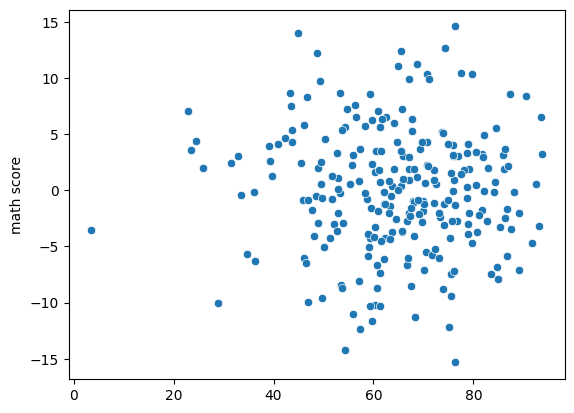

In [27]:
'''Linear Regression seems to be performing well with R2 score of 0.85 on test set. We can further tune the hyperparameters of the model to improve the performance.'''
residuals=y_test - models['Linear Regression'].predict(X_test)
sns.scatterplot(x=models['Linear Regression'].predict(X_test), y=residuals)